In [ ]:
# Libraries 
import numpy as np

# Supervised Learning

Now we move to the supervised learning of our models in which we will try to get the best predictive performance we can, and select the best performing models and parameters for the final predictions.


## Dropseq

### MCF7

We start with the Dropseq MCF7 case and we begin with a logistic regression. Our dataset is already normalized, which is important for this type of model, otherwise the results might be skewed. We see that the best performing parameters are {'C': 1, 'solver': 'lbfgs'}, and we get an accuracy of an average 97% over 5-fold cross-validation. This is a very good result and not too surprising given the relatively good performance of our dataset in unsupervised learning.

More specifically, we use a split on the training data (i.e. we split the training data that is given to us in the project). On the train split of the training data, we perform grid search and cross-validation to get the best model, and then we use that model to check its performance on data it has never seen (i.e. the test split of our training set).


#### Logistic Regression (97% ACCURACY)

In [484]:
logreg=LogisticRegression(random_state=0)

y_clean_MCF7 = [element.strip('""').split("_")[1] for element in y_train_MCF7]
color_MCF7 = [0 if element == "Normoxia" else 1 for element in y_clean_MCF7]
output_MCF7 = color_MCF7

X_train_MCF7.shape, len(output_MCF7)

((13641, 50), 13641)

In [485]:
# HYPERTUNING WITH GRIDSEARCHCV
param_grid = {            
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(logreg,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_MCF7, output_MCF7)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 0.1, 'solver': 'lbfgs'}
CV accuracy : 0.9794735645918875


In [486]:
y_pred = best_model.predict(X_test_MCF7)

y_clean_MCF7 = [element.strip('""').split("_")[1] for element in y_test_MCF7]
y_test = [0 if element == "Normoxia" else 1 for element in y_clean_MCF7]
y_test = np.array(y_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))
print(y_pred.shape, y_test.shape)

[[1 1]
 [0 1]
 [0 0]
 ...
 [1 1]
 [0 0]
 [0 0]]
(3411,) (3411,)


In [487]:
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_MCF7)[:, 1]))

Test accuracy : 0.980650835532102
Confusion mat: [[1755   29]
 [  37 1590]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1784
           1       0.98      0.98      0.98      1627

    accuracy                           0.98      3411
   macro avg       0.98      0.98      0.98      3411
weighted avg       0.98      0.98      0.98      3411

ROC-AUC: 0.9976269289815087


Here we once again show the results of our best model in the gridsearch using the cross calidation. 

In [489]:
cv_scores = cross_val_score(
    best_model,          
    X_train_MCF7,        
    output_MCF7,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9795 ± 0.0013


#### K-Nearest Neighbors (94.5% ACCURACY)

The code follow the same format as in the logistic regression but this time we get a lower but still impressive accuracy of 94.5 percent. 

In [492]:
knn = KNeighborsClassifier()

In [493]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan','minkowski']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(knn,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_MCF7, output_MCF7)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
CV accuracy : 0.9744887915073142


In [494]:
#TESTING METRICS

y_pred = best_model.predict(X_test_MCF7)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_MCF7)[:, 1]))

Test accuracy : 0.9730284374083846
Confusion mat: [[1763   21]
 [  71 1556]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1784
           1       0.99      0.96      0.97      1627

    accuracy                           0.97      3411
   macro avg       0.97      0.97      0.97      3411
weighted avg       0.97      0.97      0.97      3411

ROC-AUC: 0.994257154354351


In [495]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_MCF7,        
    output_MCF7,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9745 ± 0.0022


#### Support Vector Machine and Kernel SVM (97% ACCURACY)

Moving to the SVM, again with the same format, we are back to the 97% accuracy which we got with the logistic regression as well. This suggests that in all of our dimensions, the data is quite linearly separable. This result is also confirmed below by the very little improvement when using kernel SVM.


In [498]:
svm = SVC(random_state=0, class_weight='balanced')

In [499]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [
    # linear kernel
    {'kernel': ['linear'],
     'C': [0.1, 1, 10, 100]},

    # RBF kernel
    #{'kernel': ['rbf'],
     #'C':     [0.1, 1, 10, 100],
     #'gamma': ['scale', 'auto', 0.01, 0.001]}
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(svm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_MCF7, output_MCF7)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 0.1, 'kernel': 'linear'}
CV accuracy : 0.9794002508088964


In [500]:
# TESTING METRICS

y_pred = best_model.predict(X_test_MCF7)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy : 0.9812371738493111
Confusion mat: [[1754   30]
 [  34 1593]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1784
           1       0.98      0.98      0.98      1627

    accuracy                           0.98      3411
   macro avg       0.98      0.98      0.98      3411
weighted avg       0.98      0.98      0.98      3411



In [501]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_MCF7,        
    output_MCF7,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9794 ± 0.0013


#### Kernel Support Vector Machine (97.5% ACCURACY)

In [503]:
ksvm = SVC(random_state=0, class_weight='balanced')

In [504]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [
    # RBF kernel
    {'kernel': ['rbf'],
     'C':     [0.1, 1, 10, 100],
     'gamma': ['scale', 0.01, 0.001]}
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

gs = GridSearchCV(ksvm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_MCF7, output_MCF7)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
CV accuracy : 0.9846785426288395


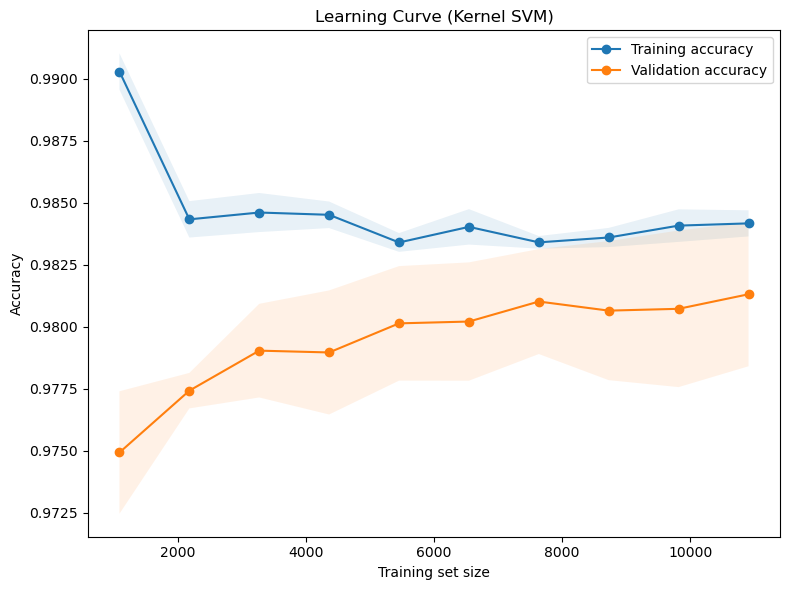

In [505]:
ksvm_final = SVC(kernel= 'rbf', C=100, gamma= 0.001, random_state=0, class_weight='balanced')

train_sizes, train_scores, val_scores = learning_curve(
    ksvm_final,
    X_train_MCF7, output_MCF7,
    cv=5,                        
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),  
    n_jobs=-1                     
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training accuracy")
plt.plot(train_sizes, val_mean, 'o-', label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Kernel SVM)")
plt.legend()
plt.tight_layout()
plt.show()

In [506]:
# TESTING METRICS

y_pred = best_model.predict(X_test_MCF7)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy : 0.9873937261800059
Confusion mat: [[1763   21]
 [  22 1605]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1784
           1       0.99      0.99      0.99      1627

    accuracy                           0.99      3411
   macro avg       0.99      0.99      0.99      3411
weighted avg       0.99      0.99      0.99      3411



In [507]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_MCF7,        
    output_MCF7,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9847 ± 0.0004


#### Naive Bayes (82% ACCURACY)

In the Naive Bayes model we get significantly lower accuracy than on the previous models. Since the Naive Bayes model assumes that the features are conditionally independent, a lower accuracy would suggest that our dataset does not meet these expectations. Our dataset likely has more complex feature interactions and thus we get a lower result here than in the previous cases.


In [510]:
gnb = GaussianNB()

In [511]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(gnb,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_MCF7, output_MCF7)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'var_smoothing': 1e-09}
CV accuracy : 0.9447255179246692


In [512]:
# TESTING METRICS

y_pred = best_model.predict(X_test_MCF7)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_MCF7)[:, 1]))

Test accuracy : 0.9460568748167693
Confusion mat: [[1675  109]
 [  75 1552]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1784
           1       0.93      0.95      0.94      1627

    accuracy                           0.95      3411
   macro avg       0.95      0.95      0.95      3411
weighted avg       0.95      0.95      0.95      3411

ROC-AUC: 0.9874707500392756


In [513]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_MCF7,        
    output_MCF7,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9447 ± 0.0047


#### Random Forest (94.6% ACCURACY)

Moving to the random forests we get an accuracy of around 94%. Random forests are sometimes prone to overfitting but looking at the results of our predictions on the test set we see that the model is well trained.  

In [516]:
RF = RandomForestClassifier(random_state=0, class_weight='balanced')

In [517]:
param_dist = {
    'n_estimators':  randint(50, 400),         
    'max_depth':     [None, 10, 20, 40],
    'max_features':  ['sqrt', 'log2'],
    'min_samples_split': randint(2, 11),        
    'min_samples_leaf':  randint(1, 5)          
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

rs = RandomizedSearchCV(
        RF,
        param_distributions = param_dist,
        n_iter      = 40,       # draw 40 random combos
        cv          = cv,
        scoring     = 'accuracy',
        n_jobs      = -1,
        random_state= 0)

rs.fit(X_train_MCF7, output_MCF7)

best_rf = rs.best_estimator_
print("best params :", rs.best_params_)
print("CV accuracy :", rs.best_score_)


best params : {'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 215}
CV accuracy : 0.9711164870610659


In [518]:
# TESTING METRICS

y_pred = best_rf.predict(X_test_MCF7)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_MCF7)[:, 1]))

Test accuracy : 0.9724420990911756
Confusion mat: [[1745   39]
 [  55 1572]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1784
           1       0.98      0.97      0.97      1627

    accuracy                           0.97      3411
   macro avg       0.97      0.97      0.97      3411
weighted avg       0.97      0.97      0.97      3411

ROC-AUC: 0.9874707500392756


In [519]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_rf,          
    X_train_MCF7,        
    output_MCF7,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9711 ± 0.0014


### HCC1806

The situation with the DropSeq HCC1806 is quite similar, but we see that on average the models perform a bit worse than on the DropSeq MCF7. This again builds on to our observations during the unsupervised learning that this dataset is a bit more complex and the classes are not as clearly separated. As in the MCF7 case, our best performance is the Kernel SVM, but this time the increase in accuracy from the regular SVM is along the lines of 2%. This again is not too drastic but also suggests that the data is a bit less linearly separable in its original dimensions than the DropSeq MCF7 data.

From the confusion matrices in the models below, we see that all of the models perform similarly on the test set as they did during cross-validation, which again suggests no overfitting. This again is not too surprising given that we use cross-validation for training, which does not allow us to overfit too much.


#### Logistic Regression (94.5% ACCURACY)

In [523]:
logreg = LogisticRegression(random_state = 0)
y_clean_HCC1806 = [element.strip('""').split("_")[1] for element in y_train_HCC1806]
color_HCC1806 = [0 if element == "Normoxia" else 1 for element in y_clean_HCC1806]
output_HCC1806 = color_HCC1806

X_train_MCF7.shape, len(output_MCF7)

((13641, 50), 13641)

In [524]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {            
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(logreg,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_HCC1806, output_HCC1806)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 10, 'solver': 'lbfgs'}
CV accuracy : 0.9474812552966728


In [525]:
y_pred = best_model.predict(X_test_HCC1806)

y_clean_HCC1806 = [element.strip('""').split("_")[1] for element in y_test_HCC1806]
y_test = [0 if element == "Normoxia" else 1 for element in y_clean_HCC1806]
y_test = np.array(y_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))
print(y_pred.shape, y_test.shape)

[[1 1]
 [1 1]
 [1 1]
 ...
 [0 0]
 [0 0]
 [0 1]]
(2242,) (2242,)


In [526]:
#TESTING METRICS

print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_HCC1806)[:, 1]))

Test accuracy : 0.943800178412132
Confusion mat: [[ 864   61]
 [  65 1252]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       925
           1       0.95      0.95      0.95      1317

    accuracy                           0.94      2242
   macro avg       0.94      0.94      0.94      2242
weighted avg       0.94      0.94      0.94      2242

ROC-AUC: 0.9862841429128445


In [527]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_HCC1806,        
    output_HCC1806,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9475 ± 0.0066


#### K-Nearest Neighbors (92% ACCURACY)

In [529]:
knn = KNeighborsClassifier()

In [530]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan','minkowski']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(knn,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_HCC1806, output_HCC1806)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
CV accuracy : 0.9249567716892336


In [531]:
#TESTING METRICS

y_pred = best_model.predict(X_test_HCC1806)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_HCC1806)[:, 1]))

Test accuracy : 0.9103479036574487
Confusion mat: [[ 880   45]
 [ 156 1161]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       925
           1       0.96      0.88      0.92      1317

    accuracy                           0.91      2242
   macro avg       0.91      0.92      0.91      2242
weighted avg       0.92      0.91      0.91      2242

ROC-AUC: 0.9747501487820394


In [532]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_HCC1806,        
    output_HCC1806,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9250 ± 0.0063


#### Support Vector Machine (94.5% ACCURACY)

In [534]:
svm = SVC(random_state=0, class_weight='balanced')

In [535]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [
    # linear kernel
    {'kernel': ['linear'],
     'C': [0.1, 1, 10, 100]},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(svm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_HCC1806, output_HCC1806)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 100, 'kernel': 'linear'}
CV accuracy : 0.9468128563887432


In [536]:
#TESTING METRICS

y_pred = best_model.predict(X_test_HCC1806)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy : 0.943800178412132
Confusion mat: [[ 876   49]
 [  77 1240]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       925
           1       0.96      0.94      0.95      1317

    accuracy                           0.94      2242
   macro avg       0.94      0.94      0.94      2242
weighted avg       0.94      0.94      0.94      2242



In [537]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_HCC1806,        
    output_HCC1806,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9468 ± 0.0076


#### Kernel Support Vector Machine (95.5% ACCURACY)

In [539]:
ksvm = SVC(random_state=0, class_weight='balanced')

In [540]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [

    # RBF kernel
    {'kernel': ['rbf'],
     'C':     [0.1, 1, 10, 100],
     'gamma': ['scale', 'auto', 0.01, 0.001]}
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

gs = GridSearchCV(ksvm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_HCC1806, output_HCC1806)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
CV accuracy : 0.9541707554231736


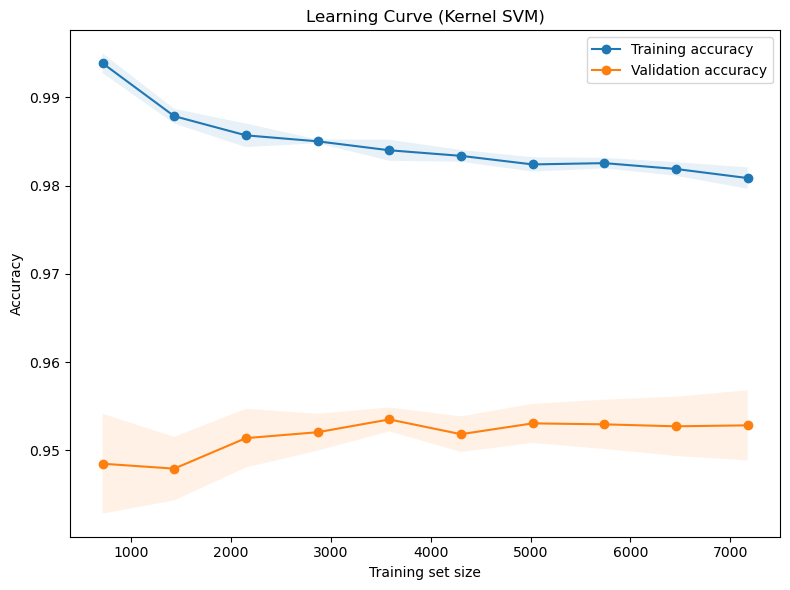

In [541]:
ksvm_final = SVC(kernel= 'rbf', C=1, gamma= 'scale', random_state=0, class_weight='balanced')

train_sizes, train_scores, val_scores = learning_curve(
    ksvm_final,
    X_train_HCC1806, output_HCC1806,
    cv=5,                        
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),  
    n_jobs=-1                     
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training accuracy")
plt.plot(train_sizes, val_mean, 'o-', label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Kernel SVM)")
plt.legend()
plt.tight_layout()
plt.show()

In [542]:
#TESTING METRICS

y_pred = best_model.predict(X_test_HCC1806)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy : 0.9509366636931311
Confusion mat: [[ 890   35]
 [  75 1242]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       925
           1       0.97      0.94      0.96      1317

    accuracy                           0.95      2242
   macro avg       0.95      0.95      0.95      2242
weighted avg       0.95      0.95      0.95      2242



In [543]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_HCC1806,        
    output_HCC1806,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9542 ± 0.0043


#### Naive Bayes (93.5% ACCURACY)

In [545]:
gnb = GaussianNB()

In [546]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(gnb,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_HCC1806, output_HCC1806)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'var_smoothing': 1e-09}
CV accuracy : 0.9351043728210973


In [547]:
#TESTING METRICS

y_pred = best_model.predict(X_test_HCC1806)
print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_HCC1806)[:, 1]))

Test accuracy : 0.9353256021409456
Confusion mat: [[ 856   69]
 [  76 1241]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       925
           1       0.95      0.94      0.94      1317

    accuracy                           0.94      2242
   macro avg       0.93      0.93      0.93      2242
weighted avg       0.94      0.94      0.94      2242

ROC-AUC: 0.9845414434936075


In [548]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_HCC1806,        
    output_HCC1806,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9351 ± 0.0078


#### Random Forest (94% ACCURACY)

In [550]:
RF = RandomForestClassifier(random_state=0, class_weight='balanced')

In [551]:
param_dist = {
    'n_estimators':  randint(50, 400),         
    'max_depth':     [None, 10, 20, 40],
    'max_features':  ['sqrt', 'log2'],
    'min_samples_split': randint(2, 11),        
    'min_samples_leaf':  randint(1, 5)          
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

rs = RandomizedSearchCV(
        RF,
        param_distributions = param_dist,
        n_iter      = 40,       
        cv          = cv,
        scoring     = 'accuracy',
        n_jobs      = -1,
        random_state= 0)

rs.fit(X_train_HCC1806, output_HCC1806)

best_rf = rs.best_estimator_
print("best params :", rs.best_params_)
print("CV accuracy :", rs.best_score_)

best params : {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 232}
CV accuracy : 0.9409019246713983


In [552]:
# TESTING METRICS

y_pred = best_rf.predict(X_test_HCC1806)

print("Test accuracy :", accuracy_score(y_test, y_pred))
print("Confusion mat:", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test_HCC1806)[:, 1]))

Test accuracy : 0.9353256021409456
Confusion mat: [[ 843   82]
 [  63 1254]]
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       925
           1       0.94      0.95      0.95      1317

    accuracy                           0.94      2242
   macro avg       0.93      0.93      0.93      2242
weighted avg       0.94      0.94      0.94      2242

ROC-AUC: 0.9845414434936075


In [553]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_rf,          
    X_train_HCC1806,        
    output_HCC1806,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9409 ± 0.0077


## SmartSeq

### MCF7

Now we move to the SmartSeq MCF7 case. Here we see that we have quite a few models that give a 100% accuracy on the cross-validation and basically all models give a 100% accuracy on the training set. This is not too surprising given our results on this dataset during the unsupervised learning. We managed to get around 94% accuracy just with k-means clustering as our data was very linearly separable. Thus more complex supervised models manage to learn the distribution perfectly and get perfect results. What is interesting, however, in this case is that the Kernel SVM is one of the worst performing models in this dataset with 96% accuracy. Of course the accuracy is very high but the comparison with the SVM and other perfect models suggest that the data is so linearly separable in its natural dimensions that using a kernel only moves us away from that separability.


#### Logistic Regression (100% ACCURACY)

In [558]:
logreg=LogisticRegression(random_state=0)

Xtrain_labels_SSMCF7_f = [0 if element == "Norm" else 1 for element in Xtrain_labels_SSMCF7]
Xtest_labels_SSMCF7_f = [0 if element == "Norm" else 1 for element in Xtest_labels_SSMCF7]

Xtrain_labels_SSMCF7_f = np.array(Xtrain_labels_SSMCF7_f)
Xtest_labels_SSMCF7_f = np.array(Xtest_labels_SSMCF7_f)

print(Xtrain_labels_SSMCF7_f.shape, Xtest_labels_SSMCF7_f.shape)

(200,) (50,)


In [559]:
# HYPERTUNING WITH GRIDSEARCHCV
param_grid = {            
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(logreg,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSMCF7, Xtrain_labels_SSMCF7_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 0.01, 'solver': 'lbfgs'}
CV accuracy : 1.0


In [560]:
y_pred = best_model.predict(X_test_pca_SSMCF7)

print("Test accuracy :", accuracy_score(Xtest_labels_SSMCF7_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSMCF7_f, y_pred))
print(classification_report(Xtest_labels_SSMCF7_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSMCF7_f, best_model.predict_proba(X_test_pca_SSMCF7)[:, 1]))

Test accuracy : 1.0
Confusion mat: [[26  0]
 [ 0 24]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        24

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

ROC-AUC: 1.0


In [561]:
cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSMCF7,        
    Xtrain_labels_SSMCF7_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 1.0000 ± 0.0000


In [563]:
knn = KNeighborsClassifier()

In [564]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan','minkowski']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(knn,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSMCF7, Xtrain_labels_SSMCF7_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
CV accuracy : 0.9949999999999999


In [565]:
y_pred = best_model.predict(X_test_pca_SSMCF7)

print("Test accuracy :", accuracy_score(Xtest_labels_SSMCF7_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSMCF7_f, y_pred))
print(classification_report(Xtest_labels_SSMCF7_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSMCF7_f, best_model.predict_proba(X_test_pca_SSMCF7)[:, 1]))

Test accuracy : 1.0
Confusion mat: [[26  0]
 [ 0 24]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        24

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

ROC-AUC: 1.0


In [566]:
cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSMCF7,        
    Xtrain_labels_SSMCF7_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9950 ± 0.0100


#### Support Vector Machine and Kernel SVM (100% ACCURACY)

In [568]:
svm = SVC(random_state=0, class_weight='balanced')

In [569]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [
    # linear kernel
    {'kernel': ['linear'],
     'C': [0.1, 1, 10, 100]},

    # RBF kernel
    #{'kernel': ['rbf'],
     #'C':     [0.1, 1, 10, 100],
     #'gamma': ['scale', 'auto', 0.01, 0.001]}
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(svm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_pca_SSMCF7, Xtrain_labels_SSMCF7_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 0.1, 'kernel': 'linear'}
CV accuracy : 1.0


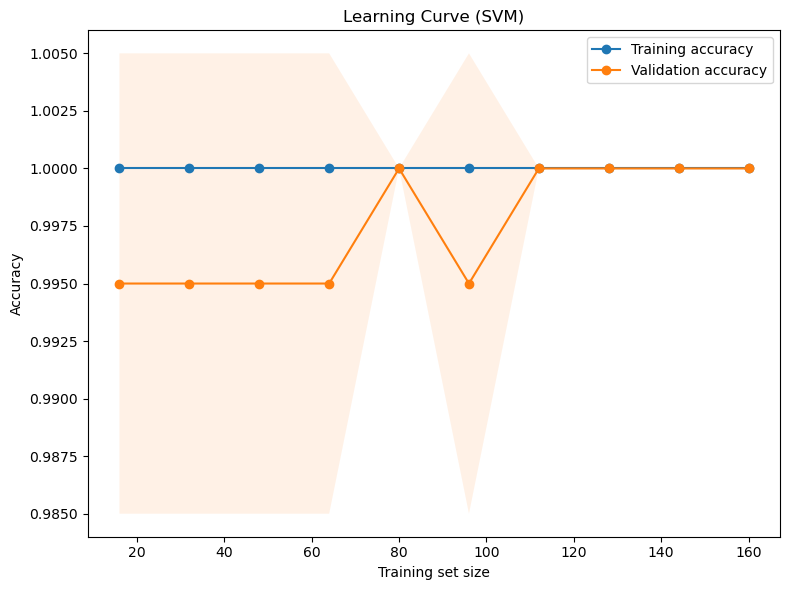

In [570]:
svm_final = SVC(kernel= 'linear', C=1, random_state=0, class_weight='balanced')

train_sizes, train_scores, val_scores = learning_curve(
    svm_final,
    X_train_pca_SSMCF7, Xtrain_labels_SSMCF7_f,
    cv=5,                        
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),  
    n_jobs=-1                     
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training accuracy")
plt.plot(train_sizes, val_mean, 'o-', label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (SVM)")
plt.legend()
plt.tight_layout()
plt.show()

In [571]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSMCF7)

print("Test accuracy :", accuracy_score(Xtest_labels_SSMCF7_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSMCF7_f, y_pred))
print(classification_report(Xtest_labels_SSMCF7_f, y_pred))

Test accuracy : 1.0
Confusion mat: [[26  0]
 [ 0 24]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        24

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [572]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSMCF7,        
    Xtrain_labels_SSMCF7_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 1.0000 ± 0.0000


#### Kernel Support Vector Machine (100% ACCURACY)

In [574]:
ksvm = SVC(random_state=0, class_weight='balanced')

In [575]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [
    # RBF kernel
    {'kernel': ['rbf'],
     'C':     [0.1, 1, 10, 100],
     'gamma': ['scale', 0.01, 0.001]}
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

gs = GridSearchCV(ksvm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_pca_SSMCF7, Xtrain_labels_SSMCF7_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
CV accuracy : 1.0


In [576]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSMCF7)

print("Test accuracy :", accuracy_score(Xtest_labels_SSMCF7_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSMCF7_f, y_pred))
print(classification_report(Xtest_labels_SSMCF7_f, y_pred))

Test accuracy : 1.0
Confusion mat: [[26  0]
 [ 0 24]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        24

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [577]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSMCF7,        
    Xtrain_labels_SSMCF7_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 1.0000 ± 0.0000


#### Naive Bayes (92% ACCURACY)

In [579]:
gnb = GaussianNB()

In [580]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(gnb,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSMCF7, Xtrain_labels_SSMCF7_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'var_smoothing': 1e-09}
CV accuracy : 0.915


In [581]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSMCF7)

print("Test accuracy :", accuracy_score(Xtest_labels_SSMCF7_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSMCF7_f, y_pred))
print(classification_report(Xtest_labels_SSMCF7_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSMCF7_f, best_model.predict_proba(X_test_pca_SSMCF7)[:, 1]))

Test accuracy : 0.86
Confusion mat: [[26  0]
 [ 7 17]]
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        26
           1       1.00      0.71      0.83        24

    accuracy                           0.86        50
   macro avg       0.89      0.85      0.86        50
weighted avg       0.89      0.86      0.86        50

ROC-AUC: 0.9983974358974359


In [582]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSMCF7,        
    Xtrain_labels_SSMCF7_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9150 ± 0.0374


#### Random Forest (99% ACCURACY)

In [584]:
RF = RandomForestClassifier(random_state=0, class_weight='balanced')

In [585]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [None, 10, 20, 40],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(RF,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSMCF7, Xtrain_labels_SSMCF7_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
CV accuracy : 0.99


In [586]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSMCF7)

print("Test accuracy :", accuracy_score(Xtest_labels_SSMCF7_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSMCF7_f, y_pred))
print(classification_report(Xtest_labels_SSMCF7_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSMCF7_f, best_model.predict_proba(X_test_pca_SSMCF7)[:, 1]))

Test accuracy : 0.98
Confusion mat: [[26  0]
 [ 1 23]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.96      0.98        24

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50

ROC-AUC: 1.0


In [587]:
# CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSMCF7,        
    Xtrain_labels_SSMCF7_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9900 ± 0.0122


### HCC1806

Now we move to the SmartSeq HCC1806 case. Again we see very high accuracies of above 95% on most of the models. What is interesting is that again in the HCC1806 case, just like in DropSeq, the Naive Bayes model severely underperforms the others. This could be presenting some underlying biological feature of the HCC1806 cells given that we get similar results for both sequencing methods. In this case, the drop off in accuracy is much larger but this could also be due to the relatively smaller sample size in the SmartSeq datasets.


#### Logistic Regression (97.9% ACCURACY)

In [591]:
logreg=LogisticRegression(random_state=0)
Xtrain_labels_SSHCC1806_f = [0 if element == "Normo" else 1 for element in Xtrain_labels_SSHCC1806]
Xtest_labels_SSHCC1806_f = [0 if element == "Normo" else 1 for element in Xtest_labels_SSHCC1806]

Xtrain_labels_SSHCC1806_f = np.array(Xtrain_labels_SSHCC1806_f)
Xtest_labels_SSHCC1806_f = np.array(Xtest_labels_SSHCC1806_f)

print(Xtrain_labels_SSHCC1806_f.shape, Xtest_labels_SSHCC1806_f.shape)

(145,) (37,)


In [592]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {            
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(logreg,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSHCC1806, Xtrain_labels_SSHCC1806_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 0.01, 'solver': 'lbfgs'}
CV accuracy : 0.9724137931034484


In [593]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSHCC1806)

print("Test accuracy :", accuracy_score(Xtest_labels_SSHCC1806_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSHCC1806_f, y_pred))
print(classification_report(Xtest_labels_SSHCC1806_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSHCC1806_f, best_model.predict_proba(X_test_pca_SSHCC1806)[:, 1]))

Test accuracy : 0.972972972972973
Confusion mat: [[13  0]
 [ 1 23]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.96      0.98        24

    accuracy                           0.97        37
   macro avg       0.96      0.98      0.97        37
weighted avg       0.97      0.97      0.97        37

ROC-AUC: 0.9583333333333334


In [594]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSHCC1806,        
    Xtrain_labels_SSHCC1806_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9724 ± 0.0258


#### K-Nearest Neighbors (95% ACCURACY)

In [596]:
knn = KNeighborsClassifier()

In [597]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan','minkowski']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(knn,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSHCC1806, Xtrain_labels_SSHCC1806_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
CV accuracy : 0.9517241379310345


In [598]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSHCC1806)

print("Test accuracy :", accuracy_score(Xtest_labels_SSHCC1806_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSHCC1806_f, y_pred))
print(classification_report(Xtest_labels_SSHCC1806_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSHCC1806_f, best_model.predict_proba(X_test_pca_SSHCC1806)[:, 1]))

Test accuracy : 0.972972972972973
Confusion mat: [[13  0]
 [ 1 23]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.96      0.98        24

    accuracy                           0.97        37
   macro avg       0.96      0.98      0.97        37
weighted avg       0.97      0.97      0.97        37

ROC-AUC: 0.9775641025641026


In [599]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSHCC1806,        
    Xtrain_labels_SSHCC1806_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9517 ± 0.0276


#### Support Vector Machine (98.6% ACCURACY)

In [601]:
svm = SVC(random_state=0, class_weight='balanced')

In [602]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [
    # linear kernel
    {'kernel': ['linear'],
     'C': [0.1, 1, 10, 100]},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(svm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_pca_SSHCC1806, Xtrain_labels_SSHCC1806_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 0.1, 'kernel': 'linear'}
CV accuracy : 0.9862068965517242


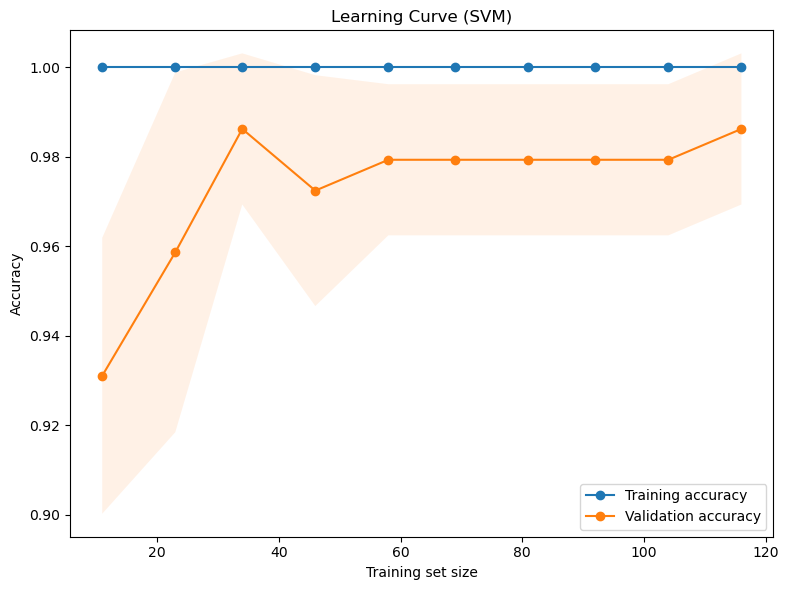

In [603]:
svm_final = SVC(kernel= 'linear', C=0.1, random_state=0, class_weight='balanced')

train_sizes, train_scores, val_scores = learning_curve(
    svm_final,
    X_train_pca_SSHCC1806, Xtrain_labels_SSHCC1806_f,
    cv=5,                        
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),  
    n_jobs=-1                     
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training accuracy")
plt.plot(train_sizes, val_mean, 'o-', label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (SVM)")
plt.legend()
plt.tight_layout()
plt.show()

In [604]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSHCC1806)

print("Test accuracy :", accuracy_score(Xtest_labels_SSHCC1806_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSHCC1806_f, y_pred))
print(classification_report(Xtest_labels_SSHCC1806_f, y_pred))

Test accuracy : 0.972972972972973
Confusion mat: [[13  0]
 [ 1 23]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.96      0.98        24

    accuracy                           0.97        37
   macro avg       0.96      0.98      0.97        37
weighted avg       0.97      0.97      0.97        37



In [605]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSHCC1806,        
    Xtrain_labels_SSHCC1806_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9862 ± 0.0169


#### Kernel Support Vector Machine (97.2% ACCURACY)

In [607]:
ksvm = SVC(random_state=0, class_weight='balanced')

In [608]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = [

    # RBF kernel
    {'kernel': ['rbf'],
     'C':     [0.1, 1, 10, 100],
     'gamma': ['scale', 'auto', 0.01, 0.001]}
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

gs = GridSearchCV(ksvm,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=1)  

gs.fit(X_train_pca_SSHCC1806, Xtrain_labels_SSHCC1806_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
CV accuracy : 0.9725056689342404


In [609]:
# TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSHCC1806)

print("Test accuracy :", accuracy_score(Xtest_labels_SSHCC1806_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSHCC1806_f, y_pred))
print(classification_report(Xtest_labels_SSHCC1806_f, y_pred))

Test accuracy : 0.972972972972973
Confusion mat: [[13  0]
 [ 1 23]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.96      0.98        24

    accuracy                           0.97        37
   macro avg       0.96      0.98      0.97        37
weighted avg       0.97      0.97      0.97        37



In [610]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSHCC1806,        
    Xtrain_labels_SSHCC1806_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9725 ± 0.0194


#### Naive Bayes (93% ACCURACY)

In [612]:
gnb = GaussianNB()

In [613]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(gnb,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSHCC1806, Xtrain_labels_SSHCC1806_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'var_smoothing': 1e-09}
CV accuracy : 0.9241379310344827


In [614]:
#TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSHCC1806)

print("Test accuracy :", accuracy_score(Xtest_labels_SSHCC1806_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSHCC1806_f, y_pred))
print(classification_report(Xtest_labels_SSHCC1806_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSHCC1806_f, best_model.predict_proba(X_test_pca_SSHCC1806)[:, 1]))

Test accuracy : 0.972972972972973
Confusion mat: [[12  1]
 [ 0 24]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.96      1.00      0.98        24

    accuracy                           0.97        37
   macro avg       0.98      0.96      0.97        37
weighted avg       0.97      0.97      0.97        37

ROC-AUC: 1.0


In [615]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSHCC1806,        
    Xtrain_labels_SSHCC1806_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9241 ± 0.0507


#### Random Forest (97.2% ACCURACY)

In [617]:
RF = RandomForestClassifier(random_state=0, class_weight='balanced')

In [618]:
# HYPERTUNING WITH GRIDSEARCHCV

param_grid = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [None, 10, 20, 40],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(RF,
                  param_grid=param_grid,
                  cv=cv,
                  scoring='accuracy',
                  n_jobs=-1)  

gs.fit(X_train_pca_SSHCC1806, Xtrain_labels_SSHCC1806_f)

best_model = gs.best_estimator_
print("Best params :", gs.best_params_)
print("CV accuracy :", gs.best_score_)

Best params : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
CV accuracy : 0.9724137931034484


In [619]:
#TESTING METRICS

y_pred = best_model.predict(X_test_pca_SSHCC1806)

print("Test accuracy :", accuracy_score(Xtest_labels_SSHCC1806_f, y_pred))
print("Confusion mat:", confusion_matrix(Xtest_labels_SSHCC1806_f, y_pred))
print(classification_report(Xtest_labels_SSHCC1806_f, y_pred))
print("ROC-AUC:", roc_auc_score(Xtest_labels_SSHCC1806_f, best_model.predict_proba(X_test_pca_SSHCC1806)[:, 1]))

Test accuracy : 1.0
Confusion mat: [[13  0]
 [ 0 24]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        24

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

ROC-AUC: 1.0


In [620]:
#CROSS VALIDATION SCORE

cv_scores = cross_val_score(
    best_model,          
    X_train_pca_SSHCC1806,        
    Xtrain_labels_SSHCC1806_f,         
    cv=cv,               
    scoring='accuracy'
)
print(f"CV accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV accuracy  : 0.9724 ± 0.0258


## Supervised Learning Conslusion

In conclusion of the supervised learning, we got very impressive results on each of the datasets. On both of the DropSeq cases, the best performance was achieved by the kernel support vector machine with an accuracy of 97.5% for the MCF7 cells and an accuracy of 94% in the HCC1806 cells. In the SmartSeq databases we got also amazing results, especially in the MCF7 case where we had multiple models with 100% accuracy. Specifically they were logistic regression, support vector machine, and random forest. In the HCC1806 case the best performing model was the logistic regression with 98.6% accuracy. What we also noticed is that on the SmartSeq method we managed to get higher accuracy than in the DropSeq case which suggests that deeper sequencing with fewer samples provides us more information about the underlying condition than more shallow sequencing with many samples.
